# ВКР: Предсказание популярности музыкального трека
## Level 1: EDA, дедупликация и бейзлайн (Spotify audio features)

**Среда:** Локальный ПК (Windows, GTX 1650 Super, 16GB RAM)  
**Датасет:** Spotify Tracks Dataset (114k → ~81k после дедупликации)  
**Модели:** Linear Regression, Random Forest, XGBoost, LightGBM  
**Метрики:** MAE, RMSE, R² (регрессия), Accuracy, F1, AUC-ROC (классификация)  
**Выход:** `dataset_clean.csv`, сохранённые модели и scaler

---
## 1. Импорт библиотек

In [1]:
import sys

In [2]:
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!{sys.executable} -m pip install xgboost lightgbm joblib tqdm


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!{sys.executable} -m pip install librosa soundfile resampy


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
!{sys.executable} -m pip install sentence-transformers vaderSentiment


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
!{sys.executable} -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
!{sys.executable} -m pip install tensorflow tensorflow-hub


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, time, joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, classification_report, accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
print('Все библиотеки загружены')

Все библиотеки загружены


---
## 2. Загрузка и первичный осмотр

In [9]:
df_raw = pd.read_csv('../data/dataset.csv')

# Убираем лишний индексный столбец
if 'Unnamed: 0' in df_raw.columns:
    df_raw = df_raw.drop(columns=['Unnamed: 0'])
    print('Удалён столбец Unnamed: 0')

print(f'Исходный датасет: {len(df_raw):,} строк, {len(df_raw.columns)} колонок')
print(f'\nКолонки ({len(df_raw.columns)}):')
for col in df_raw.columns:
    print(f'  {col:25s} {str(df_raw[col].dtype):10s} nunique={df_raw[col].nunique():,}')
df_raw.head()

Удалён столбец Unnamed: 0
Исходный датасет: 114,000 строк, 20 колонок

Колонки (20):
  track_id                  object     nunique=89,741
  artists                   object     nunique=31,437
  album_name                object     nunique=46,589
  track_name                object     nunique=73,608
  popularity                int64      nunique=101
  duration_ms               int64      nunique=50,697
  explicit                  bool       nunique=2
  danceability              float64    nunique=1,174
  energy                    float64    nunique=2,083
  key                       int64      nunique=12
  loudness                  float64    nunique=19,480
  mode                      int64      nunique=2
  speechiness               float64    nunique=1,489
  acousticness              float64    nunique=5,061
  instrumentalness          float64    nunique=5,346
  liveness                  float64    nunique=1,722
  valence                   float64    nunique=1,790
  tempo              

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [10]:
print('=== Описательная статистика ===')
df_raw.describe().round(3)

=== Описательная статистика ===


,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000,114000.000
mean,33.239,228029.153,0.567,0.641,5.309,-8.259,0.638,0.085,0.315,0.156,0.214,0.474,122.148,3.904
std,22.305,107297.713,0.174,0.252,3.560,5.029,0.481,0.106,0.333,0.310,0.190,0.259,29.978,0.433
min,0.000,0.000,0.000,0.000,0.000,-49.531,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,17.000,174066.000,0.456,0.472,2.000,-10.013,0.000,0.036,0.017,0.000,0.098,0.260,99.219,4.000
50%,35.000,212906.000,0.580,0.685,5.000,-7.004,1.000,0.049,0.169,0.000,0.132,0.464,122.017,4.000
75%,50.000,261506.000,0.695,0.854,8.000,-5.003,1.000,0.084,0.598,0.049,0.273,0.683,140.071,4.000
max,100.000,5237295.000,0.985,1.000,11.000,4.532,1.000,0.965,0.996,1.000,1.000,0.995,243.372,5.000


In [11]:
print('=== Пропуски ===')
missing = df_raw.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0].to_string())
else:
    print('Пропусков нет')

print(f'\n=== Типы данных ===')
print(df_raw.dtypes.value_counts().to_string())

=== Пропуски ===
artists       1
album_name    1
track_name    1

=== Типы данных ===
float64    9
object     5
int64      5
bool       1


---
## 3. Разведочный анализ данных (EDA)

In [12]:
target = 'popularity'

print(f'=== Общая статистика ===')
print(f'Строк: {len(df_raw):,}')
print(f'Popularity: min={df_raw[target].min()}, max={df_raw[target].max()}, mean={df_raw[target].mean():.1f}, median={df_raw[target].median():.0f}, std={df_raw[target].std():.1f}')
print(f'Треков с popularity=0: {(df_raw[target]==0).sum():,} ({(df_raw[target]==0).mean()*100:.1f}%)')
print(f'Уникальных track_id: {df_raw["track_id"].nunique():,}')
print(f'Уникальных артистов: {df_raw["artists"].nunique():,}')
print(f'Уникальных жанров: {df_raw["track_genre"].nunique()}')

=== Общая статистика ===
Строк: 114,000
Popularity: min=0, max=100, mean=33.2, median=35, std=22.3
Треков с popularity=0: 16,020 (14.1%)
Уникальных track_id: 89,741
Уникальных артистов: 31,437
Уникальных жанров: 114


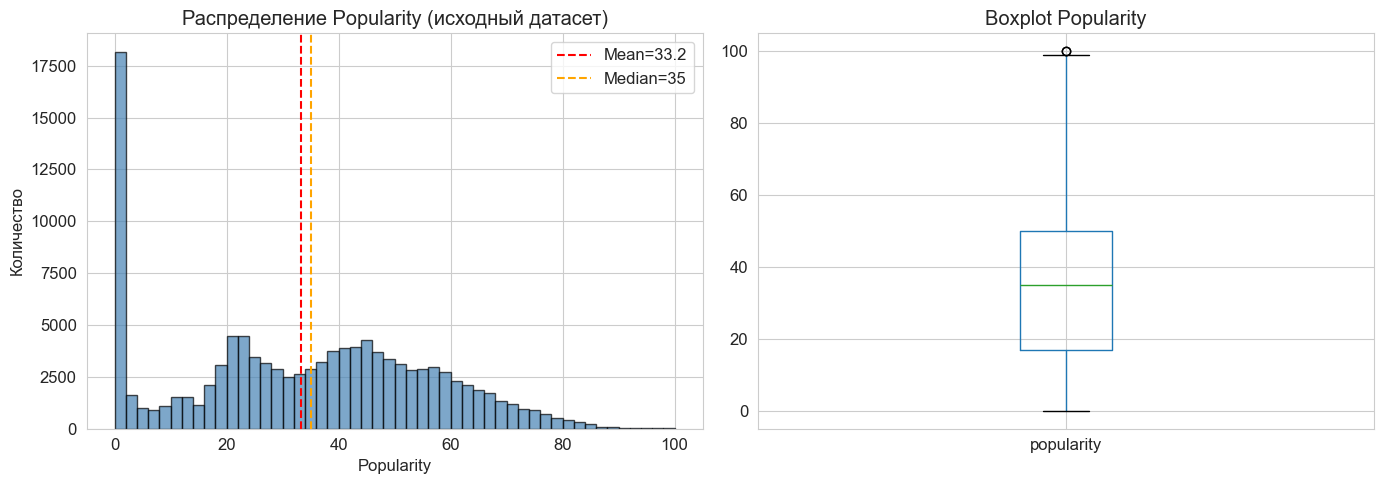

In [13]:
# 3.1 Распределение popularity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_raw[target].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(df_raw[target].mean(), color='red', linestyle='--', label=f'Mean={df_raw[target].mean():.1f}')
axes[0].axvline(df_raw[target].median(), color='orange', linestyle='--', label=f'Median={df_raw[target].median():.0f}')
axes[0].set_xlabel('Popularity'); axes[0].set_ylabel('Количество')
axes[0].set_title('Распределение Popularity (исходный датасет)'); axes[0].legend()

# Boxplot
df_raw.boxplot(column=target, ax=axes[1])
axes[1].set_title('Boxplot Popularity')
plt.tight_layout(); plt.show()

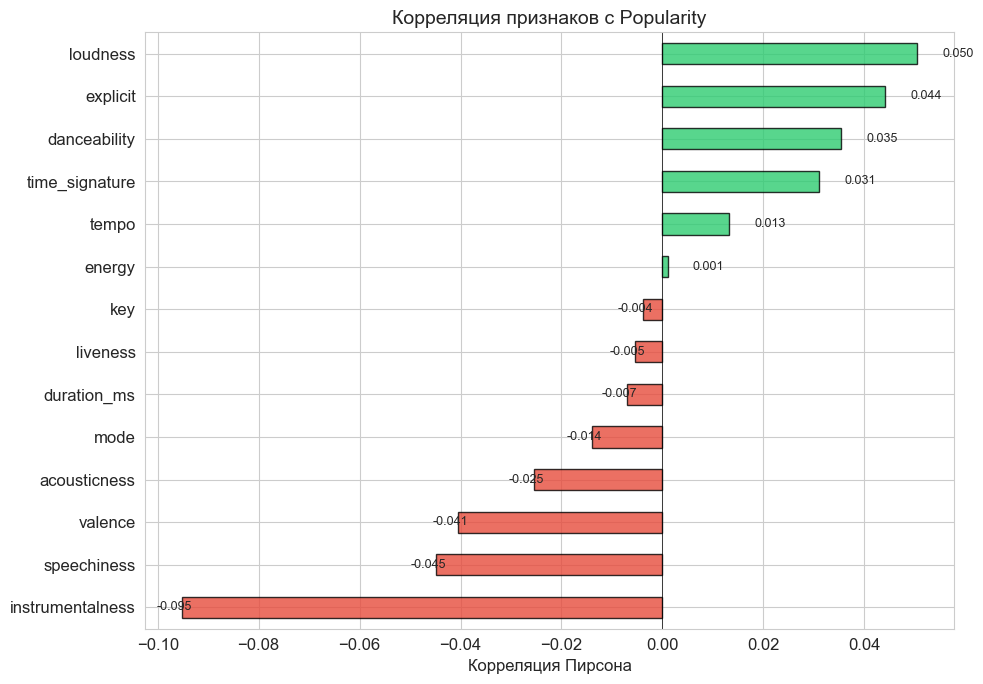

Топ-3 положительные: loudness, explicit, danceability
Топ-3 отрицательные: instrumentalness, speechiness, valence


In [14]:
# 3.2 Корреляция признаков с popularity
audio_features = ['danceability', 'energy', 'loudness', 'speechiness',
                   'acousticness', 'instrumentalness', 'liveness', 'valence',
                   'tempo', 'duration_ms']
all_features = audio_features + ['key', 'mode', 'time_signature', 'explicit']
df_raw['explicit'] = df_raw['explicit'].astype(int)

corr_with_target = df_raw[all_features + [target]].corr()[target].drop(target).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_with_target.values]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Корреляция Пирсона')
ax.set_title('Корреляция признаков с Popularity', fontsize=14)
ax.axvline(0, color='black', linewidth=0.5)
for i, v in enumerate(corr_with_target.values):
    ax.text(v + 0.005 * np.sign(v), i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(f'Топ-3 положительные: {", ".join(corr_with_target.tail(3).index[::-1])}')
print(f'Топ-3 отрицательные: {", ".join(corr_with_target.head(3).index)}')

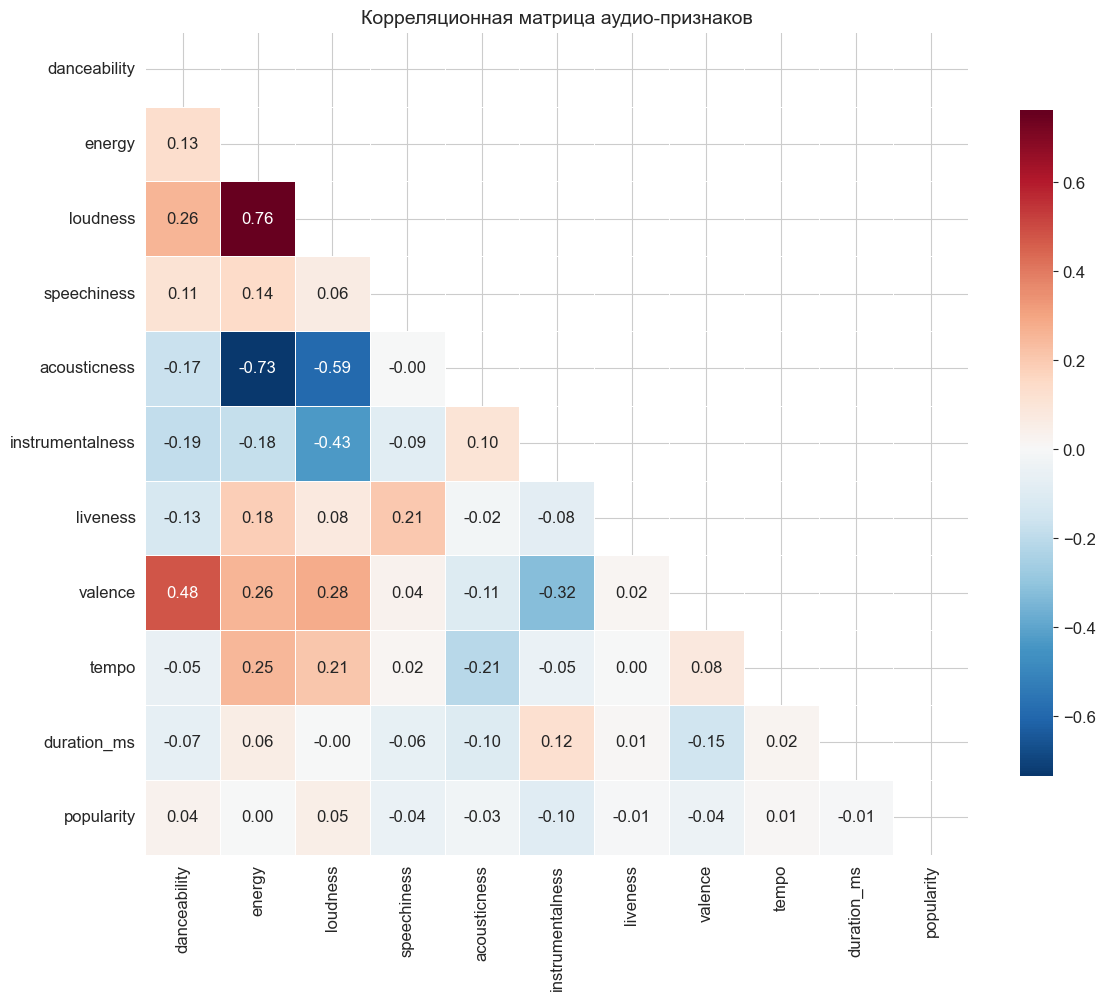

In [15]:
# 3.3 Корреляционная матрица
fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = df_raw[audio_features + [target]].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Корреляционная матрица аудио-признаков', fontsize=14)
plt.tight_layout(); plt.show()

In [16]:
# 3.4 Анализ треков с popularity = 0
df_zero = df_raw[df_raw[target] == 0]
df_nonzero = df_raw[df_raw[target] > 0]

print(f'Треков с popularity=0: {len(df_zero):,} ({len(df_zero)/len(df_raw)*100:.1f}%)')
print(f'Треков с popularity>0: {len(df_nonzero):,}')

# Топ жанров с нулевой popularity
zero_genres = df_zero['track_genre'].value_counts().head(10)
print(f'\nТоп-10 жанров с popularity=0:')
for g, c in zero_genres.items():
    total_in_genre = (df_raw['track_genre'] == g).sum()
    print(f'  {g:20s}: {c:4d} треков ({c/total_in_genre*100:.0f}% жанра)')

# Артисты с нулевой popularity
zero_artists = df_zero['artists'].value_counts()
print(f'\nАртистов с popularity=0: {zero_artists.nunique():,}')
print(f'Из них также имеют треки с popularity>0: {len(set(df_zero["artists"]) & set(df_nonzero["artists"])):,}')
print(f'\nВывод: большинство треков с popularity=0 — дубликаты или недоступные версии.')
print(f'Они будут удалены при дедупликации (останется версия с макс. popularity).')

Треков с popularity=0: 16,020 (14.1%)
Треков с popularity>0: 97,980

Топ-10 жанров с popularity=0:
  jazz                :  681 треков (68% жанра)
  iranian             :  656 треков (66% жанра)
  romance             :  636 треков (64% жанра)
  soul                :  611 треков (61% жанра)
  latin               :  588 треков (59% жанра)
  country             :  587 треков (59% жанра)
  rock                :  525 треков (52% жанра)
  dance               :  490 треков (49% жанра)
  alternative         :  485 треков (48% жанра)
  house               :  403 треков (40% жанра)

Артистов с popularity=0: 67
Из них также имеют треки с popularity>0: 1,543

Вывод: большинство треков с popularity=0 — дубликаты или недоступные версии.
Они будут удалены при дедупликации (останется версия с макс. popularity).


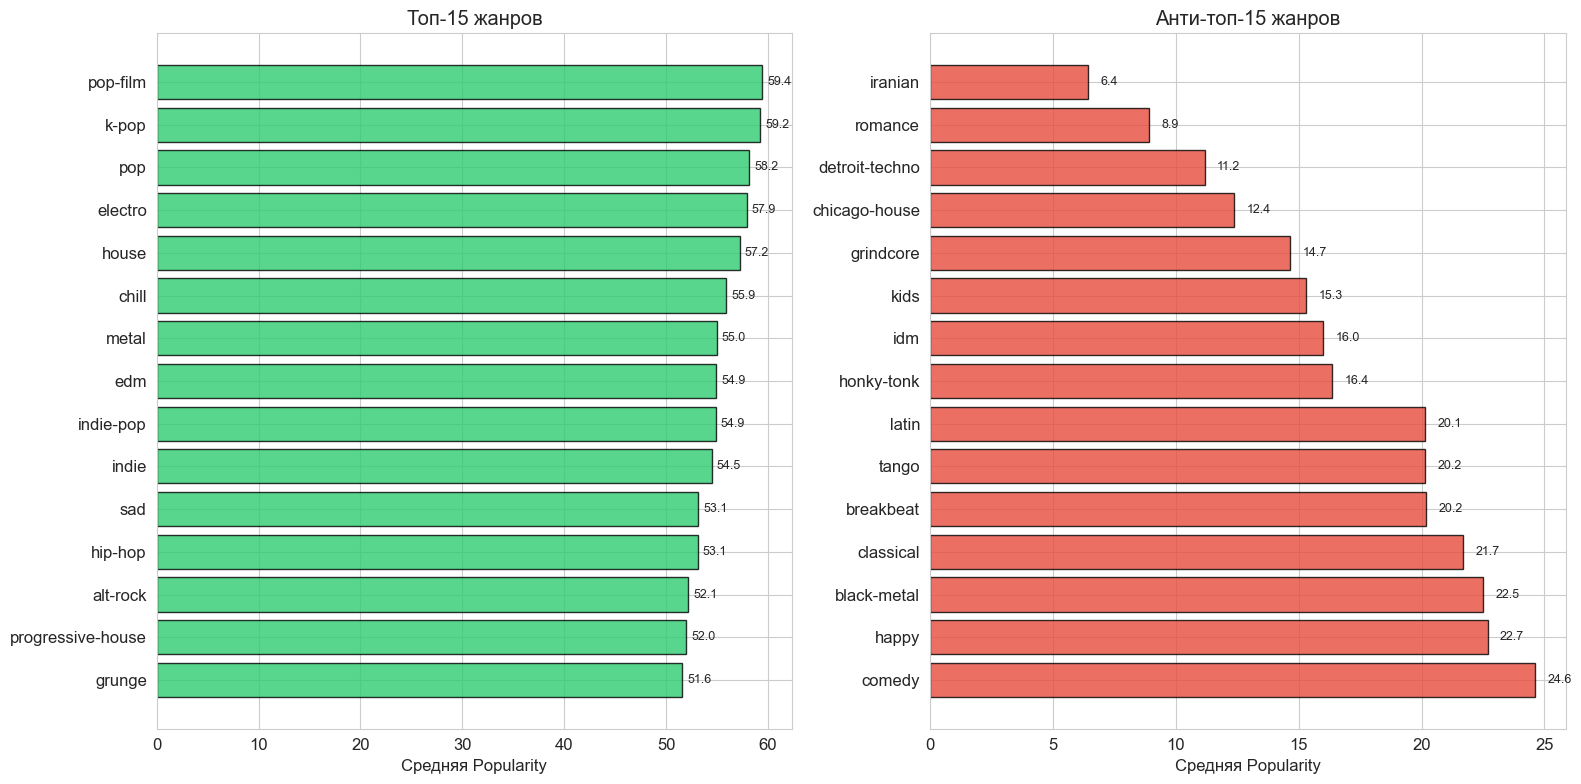

In [17]:
# 3.5 Топ/Анти-топ жанров
genre_stats = df_raw[df_raw[target]>0].groupby('track_genre')[target].agg(['mean','median','count']).sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

top15 = genre_stats.head(15)
axes[0].barh(top15.index[::-1], top15['mean'][::-1], color='#2ecc71', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Средняя Popularity'); axes[0].set_title('Топ-15 жанров')
for i, (idx, row) in enumerate(top15[::-1].iterrows()):
    axes[0].text(row['mean']+0.5, i, f'{row["mean"]:.1f}', va='center', fontsize=9)

bottom15 = genre_stats.tail(15)
axes[1].barh(bottom15.index, bottom15['mean'], color='#e74c3c', edgecolor='black', alpha=0.8)
axes[1].set_xlabel('Средняя Popularity'); axes[1].set_title('Анти-топ-15 жанров')
for i, (idx, row) in enumerate(bottom15.iterrows()):
    axes[1].text(row['mean']+0.5, i, f'{row["mean"]:.1f}', va='center', fontsize=9)

plt.tight_layout(); plt.show()

---
## 4. Дедупликация

**Двухэтапная дедупликация:**
1. По `track_id` — убирает точные дубли (один track_id в разных жанрах)
2. По `track_name + artists` — убирает ремастеры/версии с одинаковым названием

В обоих случаях сохраняем версию с **максимальной popularity**.

In [18]:
print(f'Исходный датасет: {len(df_raw):,}')
print(f'Уникальных track_id: {df_raw["track_id"].nunique():,}')

# Этап 1: дедупликация по track_id
df_step1 = (df_raw
    .sort_values(target, ascending=False)
    .drop_duplicates('track_id', keep='first')
    .reset_index(drop=True))
print(f'\nЭтап 1 (по track_id): {len(df_raw):,} → {len(df_step1):,} (удалено {len(df_raw)-len(df_step1):,})')

# Этап 2: дедупликация по track_name + artists
df_step1['_dedup_key'] = (
    df_step1['track_name'].astype(str).str.lower().str.strip() + '|||' +
    df_step1['artists'].astype(str).str.lower().str.strip()
)
dup_counts = df_step1.groupby('_dedup_key').size()
print(f'\nУникальных пар (name+artist): {len(dup_counts):,}')
print(f'Пар-дубликатов (>1): {(dup_counts > 1).sum():,}')

df = (df_step1
    .sort_values(target, ascending=False)
    .drop_duplicates('_dedup_key', keep='first')
    .drop(columns=['_dedup_key'])
    .reset_index(drop=True))
print(f'Этап 2 (по name+artist): {len(df_step1):,} → {len(df):,} (удалено {len(df_step1)-len(df):,})')

removed = len(df_raw) - len(df)
print(f'\nИТОГО: {len(df_raw):,} → {len(df):,} (удалено {removed:,}, {removed/len(df_raw)*100:.1f}%)')

Исходный датасет: 114,000
Уникальных track_id: 89,741

Этап 1 (по track_id): 114,000 → 89,741 (удалено 24,259)

Уникальных пар (name+artist): 81,207
Пар-дубликатов (>1): 4,747
Этап 2 (по name+artist): 89,741 → 81,207 (удалено 8,534)

ИТОГО: 114,000 → 81,207 (удалено 32,793, 28.8%)


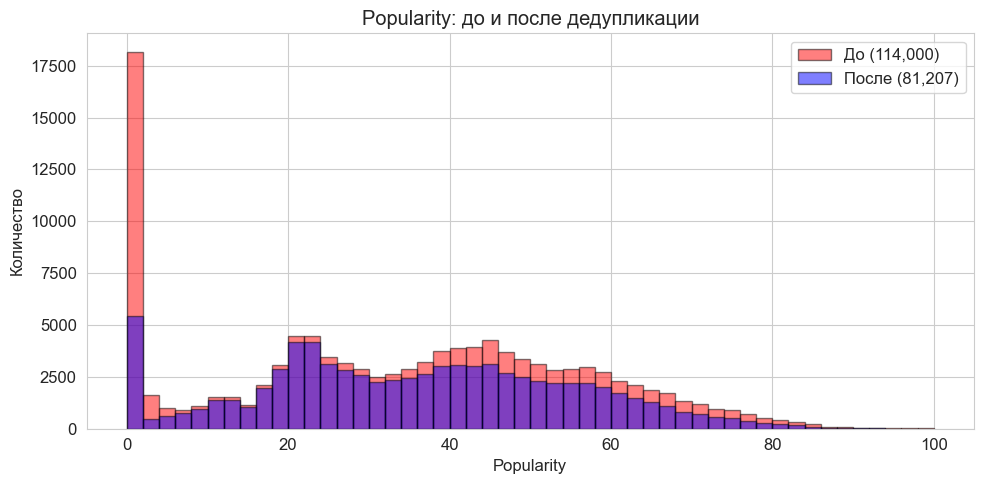

Popularity после дедупликации:
  min=0, max=100, mean=35.3, median=35
  Треков с popularity=0: 4,747 (5.8%)


In [19]:
# Визуализация дедупликации
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_raw[target], bins=50, alpha=0.5, label=f'До ({len(df_raw):,})', color='red', edgecolor='black')
ax.hist(df[target], bins=50, alpha=0.5, label=f'После ({len(df):,})', color='blue', edgecolor='black')
ax.set_xlabel('Popularity'); ax.set_ylabel('Количество')
ax.set_title('Popularity: до и после дедупликации'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Popularity после дедупликации:')
print(f'  min={df[target].min()}, max={df[target].max()}, mean={df[target].mean():.1f}, median={df[target].median():.0f}')
print(f'  Треков с popularity=0: {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%)')

---
## 5. Сохранение очищенного датасета

In [20]:
df.to_csv('dataset_clean.csv', index=False)
print(f'✅ Сохранён dataset_clean.csv: {len(df):,} треков, {len(df.columns)} колонок')
print(f'   Используется во всех последующих ноутбуках (Level 2-5)')

✅ Сохранён dataset_clean.csv: 81,207 треков, 20 колонок
   Используется во всех последующих ноутбуках (Level 2-5)


---
## 6. Уровень 1: бейзлайн

**Признаки:** 14 Spotify audio features  
**Модели:** Linear Regression, Random Forest, XGBoost, LightGBM  
**Датасет:** полный (после дедупликации)

In [21]:
spotify_features = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence',
    'tempo', 'duration_ms', 'key', 'mode', 'time_signature', 'explicit'
]

df['explicit'] = df['explicit'].astype(int)
df_l1 = df[spotify_features + [target]].dropna().reset_index(drop=True)
print(f'L1 датасет: {len(df_l1):,} треков, {len(spotify_features)} признаков')

X = df_l1[spotify_features]
y = df_l1[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
threshold = y_train.median()
y_test_bin = (y_test >= threshold).astype(int)

print(f'Train: {len(X_train):,}, Test: {len(X_test):,}')
print(f'Порог классификации (медиана train): {threshold}')
print(f'Баланс test: {y_test_bin.mean():.2%} хитов')

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

L1 датасет: 81,207 треков, 14 признаков
Train: 64,965, Test: 16,242
Порог классификации (медиана train): 35.0
Баланс test: 51.45% хитов


In [22]:
# 6.1 Обучение и оценка моделей
# Гиперпараметры одинаковые для test и CV
models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_split=10,
        min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(
        n_estimators=300, max_depth=10, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1),
}

results_l1 = {}
print(f'{"Модель":25s} | {"MAE":>7s} | {"RMSE":>7s} | {"R²":>7s} | {"AUC":>7s} | {"Время":>8s}')
print('=' * 80)

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train_s, y_train)
    yp = model.predict(X_test_s)
    t1 = time.time()
    
    mae = mean_absolute_error(y_test, yp)
    rmse = np.sqrt(mean_squared_error(y_test, yp))
    r2 = r2_score(y_test, yp)
    auc = roc_auc_score(y_test_bin, yp)
    
    results_l1[name] = {
        'MAE': mae, 'RMSE': rmse, 'R2': r2, 'AUC': auc,
        'model': model, 'y_pred': yp, 'time': t1-t0
    }
    print(f'{name:25s} | {mae:7.3f} | {rmse:7.3f} | {r2:7.4f} | {auc:7.4f} | {t1-t0:7.2f}с')

Модель                    |     MAE |    RMSE |      R² |     AUC |    Время
Linear Regression         |  15.174 |  18.674 |  0.0640 |  0.6371 |    0.02с
Random Forest             |  13.831 |  17.565 |  0.1719 |  0.7236 |   25.06с
XGBoost                   |  13.794 |  17.607 |  0.1679 |  0.7229 |    0.91с
LightGBM                  |  13.804 |  17.562 |  0.1722 |  0.7250 |    0.44с


In [23]:
# 6.2 Cross-Validation
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import LabelBinarizer

y_train_bin = (y_train >= threshold).astype(int)

print('5-fold Cross-Validation (на обучающей выборке):')
print(f'{"Модель":25s} | {"CV MAE":>12s} | {"CV RMSE":>12s} | {"CV R²":>14s} | {"CV AUC":>8s}')
print('-' * 85)

cv_models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=15, min_samples_split=10,
        min_samples_leaf=5, random_state=42, n_jobs=-1),
    'XGBoost': XGBRegressor(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbosity=0),
    'LightGBM': LGBMRegressor(
        n_estimators=300, max_depth=10, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, n_jobs=-1, verbose=-1),
}

for name, model in cv_models.items():
    cv_mae = -cross_val_score(model, X_train_s, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
    cv_rmse = np.sqrt(-cross_val_score(model, X_train_s, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1))
    cv_r2 = cross_val_score(model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
    yp_cv = cross_val_predict(model, X_train_s, y_train, cv=5, n_jobs=-1)
    auc_cv = roc_auc_score(y_train_bin, yp_cv)
    print(f'{name:25s} | {cv_mae.mean():.3f}±{cv_mae.std():.3f} | {cv_rmse.mean():.3f}±{cv_rmse.std():.3f} | {cv_r2.mean():.4f}±{cv_r2.std():.4f} | {auc_cv:.4f}')

5-fold Cross-Validation (на обучающей выборке):
Модель                    |       CV MAE |      CV RMSE |          CV R² |   CV AUC
-------------------------------------------------------------------------------------
Linear Regression         | 15.360±0.098 | 18.801±0.116 | 0.0639±0.0041 | 0.6339
Random Forest             | 14.071±0.069 | 17.766±0.088 | 0.1641±0.0049 | 0.7179
XGBoost                   | 14.026±0.070 | 17.798±0.081 | 0.1610±0.0050 | 0.7171
LightGBM                  | 14.032±0.068 | 17.767±0.084 | 0.1640±0.0046 | 0.7165


In [24]:
# 6.3 Классификация (хит / не хит)
print(f'Классификация (порог = медиана = {threshold})')
print(f'{"Модель":25s} | {"Accuracy":>10s} | {"F1-score":>10s} | {"AUC-ROC":>10s}')
print('-' * 65)

for name, r in results_l1.items():
    yp_bin = (r['y_pred'] >= threshold).astype(int)
    acc = accuracy_score(y_test_bin, yp_bin)
    f1 = f1_score(y_test_bin, yp_bin)
    print(f'{name:25s} | {acc:10.4f} | {f1:10.4f} | {r["AUC"]:10.4f}')

Классификация (порог = медиана = 35.0)
Модель                    |   Accuracy |   F1-score |    AUC-ROC
-----------------------------------------------------------------
Linear Regression         |     0.5947 |     0.6468 |     0.6371
Random Forest             |     0.6671 |     0.7052 |     0.7236
XGBoost                   |     0.6672 |     0.6972 |     0.7229
LightGBM                  |     0.6661 |     0.6979 |     0.7250


Лучшая модель по R²: LightGBM

              precision    recall  f1-score   support

      Не хит       0.69      0.58      0.63      7886
         Хит       0.65      0.75      0.70      8356

    accuracy                           0.67     16242
   macro avg       0.67      0.66      0.66     16242
weighted avg       0.67      0.67      0.66     16242



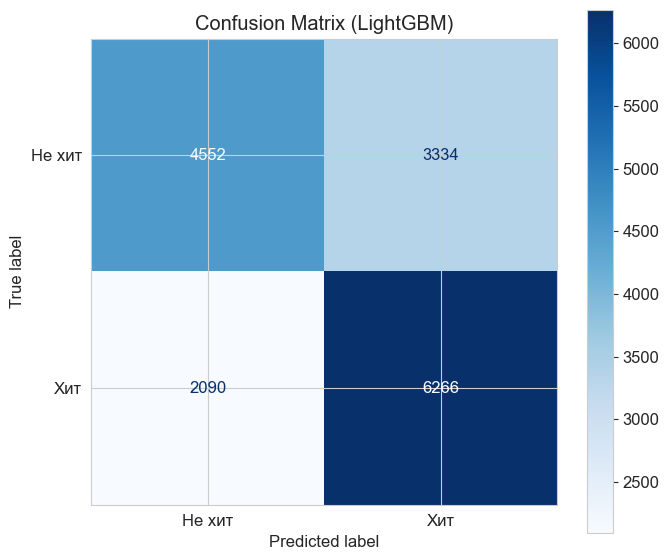

In [25]:
# 6.4 Лучшая модель — подробный отчёт
best_name = max(results_l1, key=lambda k: results_l1[k]['R2'])
best = results_l1[best_name]

print(f'Лучшая модель по R²: {best_name}\n')
yp_bin = (best['y_pred'] >= threshold).astype(int)
print(classification_report(y_test_bin, yp_bin, target_names=['Не хит', 'Хит']))

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_bin, yp_bin)
ConfusionMatrixDisplay(cm, display_labels=['Не хит', 'Хит']).plot(ax=ax, cmap='Blues')
ax.set_title(f'Confusion Matrix ({best_name})')
plt.tight_layout(); plt.show()

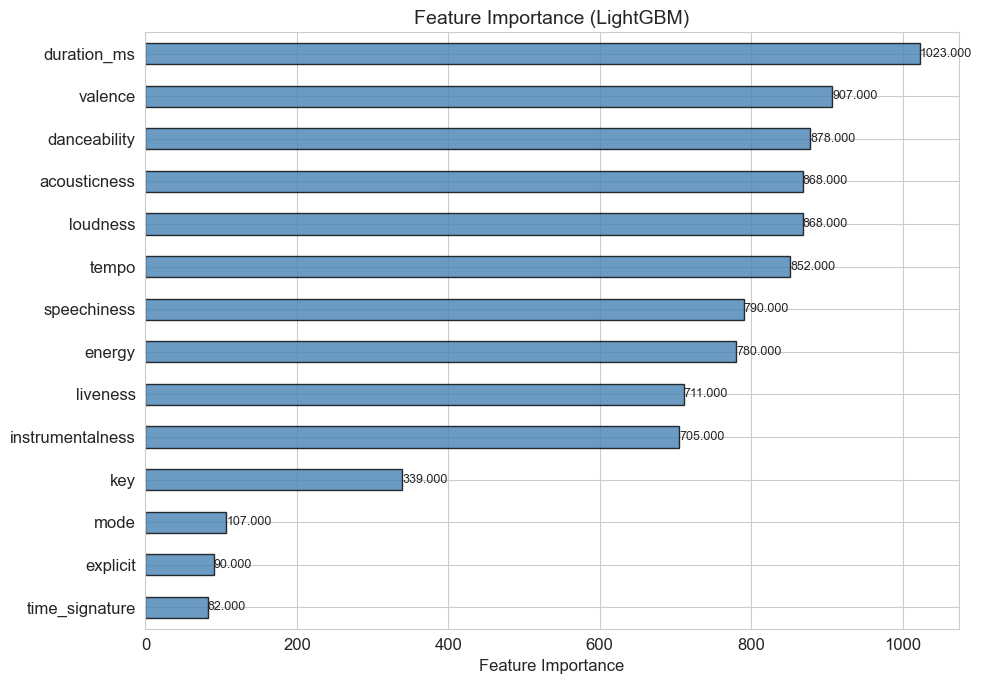

Топ-5 важных признаков: duration_ms, valence, danceability, acousticness, loudness


In [26]:
# 6.5 Feature Importance
if hasattr(best['model'], 'feature_importances_'):
    fi = pd.Series(best['model'].feature_importances_, index=spotify_features).sort_values()
else:
    fi = pd.Series(np.abs(best['model'].coef_), index=spotify_features).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
fi.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black', alpha=0.8)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Feature Importance ({best_name})', fontsize=14)
for i, v in enumerate(fi.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()

print(f'Топ-5 важных признаков: {", ".join(fi.tail(5).index[::-1])}')

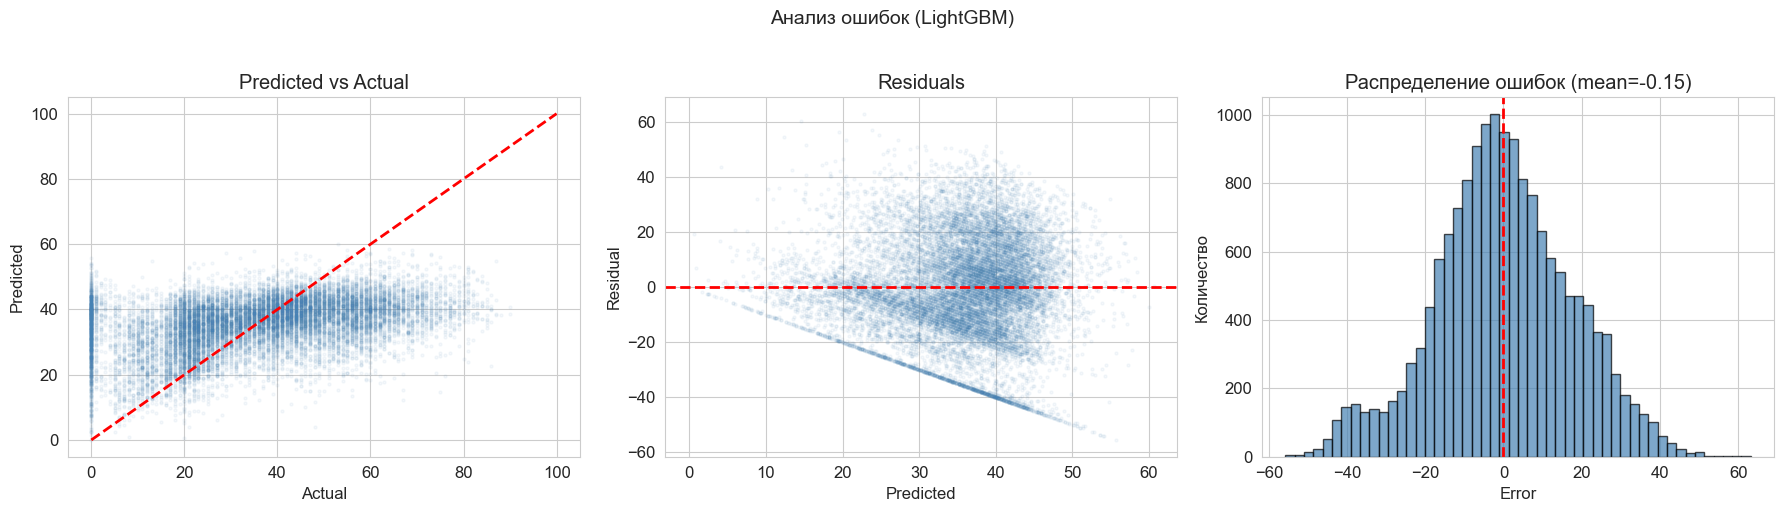

Средняя абсолютная ошибка по бинам popularity:
  (-0.09, 18.0]       : MAE= 22.10 (n=3,033.0)
  (18.0, 36.0]        : MAE=  8.82 (n=5,356.0)
  (36.0, 54.0]        : MAE=  8.07 (n=4,945.0)
  (54.0, 72.0]        : MAE= 22.07 (n=2,516.0)
  (72.0, 90.0]        : MAE= 36.92 (n=392.0)


In [27]:
# 6.6 Анализ ошибок
yp = best['y_pred']
errors = y_test.values - yp

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test, yp, alpha=0.05, s=5, c='steelblue')
axes[0].plot([0, 100], [0, 100], 'r--', lw=2)
axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')
axes[0].set_title('Predicted vs Actual')

axes[1].scatter(yp, errors, alpha=0.05, s=5, c='steelblue')
axes[1].axhline(0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residuals')

axes[2].hist(errors, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[2].axvline(0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Error'); axes[2].set_ylabel('Количество')
axes[2].set_title(f'Распределение ошибок (mean={np.mean(errors):.2f})')

plt.suptitle(f'Анализ ошибок ({best_name})', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

# MAE по бинам popularity
bins = pd.cut(y_test, bins=5)
df_err = pd.DataFrame({'actual': y_test.values, 'predicted': yp, 'abs_error': np.abs(errors), 'bin': bins})
print('Средняя абсолютная ошибка по бинам popularity:')
for idx, row in df_err.groupby('bin')['abs_error'].agg(['mean', 'count']).iterrows():
    print(f'  {str(idx):20s}: MAE={row["mean"]:6.2f} (n={row["count"]:,})')

---
## 7. Сохранение моделей

In [28]:
os.makedirs('models', exist_ok=True)

joblib.dump(scaler, 'models/scaler_l1.pkl')
for name, r in results_l1.items():
    fname = name.lower().replace(' ', '_')
    joblib.dump(r['model'], f'models/model_l1_{fname}.pkl')

print('✅ Сохранены модели и scaler:')
for f in sorted(os.listdir('models')):
    if f.startswith('model_l1') or f.startswith('scaler_l1'):
        print(f'   models/{f}')

✅ Сохранены модели и scaler:
   models/model_l1_lightgbm.pkl
   models/model_l1_linear_regression.pkl
   models/model_l1_random_forest.pkl
   models/model_l1_xgboost.pkl
   models/scaler_l1.pkl


---
## 8. Выводы

In [29]:
print('='*60)
print('ВЫВОДЫ ПО УРОВНЮ 1 (бейзлайн)')
print('='*60)

print(f'\n1. ДАТАСЕТ:')
print(f'   Исходный: {len(df_raw):,} строк')
print(f'   После дедупликации: {len(df):,} строк (удалено {len(df_raw)-len(df):,} дубликатов)')
print(f'   Треков с popularity=0: {(df[target]==0).sum():,} ({(df[target]==0).mean()*100:.1f}%)')

print(f'\n2. РЕЗУЛЬТАТЫ РЕГРЕССИИ:')
for name, r in results_l1.items():
    print(f'   {name:25s}  R²={r["R2"]:7.4f}  MAE={r["MAE"]:7.3f}  RMSE={r["RMSE"]:7.3f}')

print(f'\n3. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (хит/не хит, порог={threshold}):')
for name, r in results_l1.items():
    yp_b = (r['y_pred'] >= threshold).astype(int)
    print(f'   {name:25s}  AUC={r["AUC"]:7.4f}  Acc={accuracy_score(y_test_bin, yp_b):7.4f}  F1={f1_score(y_test_bin, yp_b):7.4f}')

best_r2 = results_l1[best_name]['R2']
print(f'''
4. ЛУЧШАЯ МОДЕЛЬ: {best_name}
   R² = {best_r2:.4f} → модель объясняет {best_r2*100:.1f}% дисперсии popularity
   MAE = {results_l1[best_name]["MAE"]:.3f} → ошибка ~{results_l1[best_name]["MAE"]:.0f} пунктов на шкале 0-100
   AUC = {results_l1[best_name]["AUC"]:.4f}

5. КЛЮЧЕВЫЕ ПРИЗНАКИ: {", ".join(fi.tail(3).index[::-1])}

6. ВЫВОД:
   14 аудио-признаков Spotify объясняют ~{best_r2*100:.0f}% дисперсии popularity.
   Это бейзлайн — последующие уровни добавят контекст артиста,
   низкоуровневый аудиоанализ (librosa, VGGish, CLAP) и текст лирики.
''')

# Сохранение результатов
results_df = pd.DataFrame([{
    'Model': k, 'R2': round(v['R2'],4), 'MAE': round(v['MAE'],3),
    'RMSE': round(v['RMSE'],3), 'AUC': round(v['AUC'],4)
} for k, v in results_l1.items()])
results_df.to_csv('level1_results.csv', index=False)
print('Сохранено: level1_results.csv, dataset_clean.csv, models/')

ВЫВОДЫ ПО УРОВНЮ 1 (бейзлайн)

1. ДАТАСЕТ:
   Исходный: 114,000 строк
   После дедупликации: 81,207 строк (удалено 32,793 дубликатов)
   Треков с popularity=0: 4,747 (5.8%)

2. РЕЗУЛЬТАТЫ РЕГРЕССИИ:
   Linear Regression          R²= 0.0640  MAE= 15.174  RMSE= 18.674
   Random Forest              R²= 0.1719  MAE= 13.831  RMSE= 17.565
   XGBoost                    R²= 0.1679  MAE= 13.794  RMSE= 17.607
   LightGBM                   R²= 0.1722  MAE= 13.804  RMSE= 17.562

3. РЕЗУЛЬТАТЫ КЛАССИФИКАЦИИ (хит/не хит, порог=35.0):
   Linear Regression          AUC= 0.6371  Acc= 0.5947  F1= 0.6468
   Random Forest              AUC= 0.7236  Acc= 0.6671  F1= 0.7052
   XGBoost                    AUC= 0.7229  Acc= 0.6672  F1= 0.6972
   LightGBM                   AUC= 0.7250  Acc= 0.6661  F1= 0.6979

4. ЛУЧШАЯ МОДЕЛЬ: LightGBM
   R² = 0.1722 → модель объясняет 17.2% дисперсии popularity
   MAE = 13.804 → ошибка ~14 пунктов на шкале 0-100
   AUC = 0.7250

5. КЛЮЧЕВЫЕ ПРИЗНАКИ: duration_ms, valence, danc